In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.svm import SVC
from tools import load_data

In [2]:
X, T, F, A, P = load_data([ps for ps in range(1, 16)], z_score_norm=None)
X = X.reshape(X.shape[0], X.shape[1] * X.shape[1])

load: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']


In [3]:
def indices_with_tolerance(arr, target, tol):
    """
    A ... angle/position or Force or Torque
    target ... target angle
    tol ... +/- tolerance
    """
    arr = np.asarray(arr)
    detected = np.where(np.abs(arr - target) <= tol)[0]
    print(f"Found {len(detected):,} for position {target} and a tolerance of {tol}.")
    return detected

In [4]:
target_F_names = [50, 75, 100, 125, 150, 175, 200]
n_classes = int(len(target_F_names))
tol = 5
targets_F = {}
targets = []
for tns in target_F_names:
    ps = indices_with_tolerance(F, tns, tol)  # Adjustment place
    np.random.shuffle(ps)
    targets_F[tns] = ps
    targets.append(ps)
targets = np.concatenate(targets)
y_label = [f"{tns}$\pm${tol}N" for tns in target_F_names]  # Adjustment place

Found 2,905 for position 50 and a tolerance of 5.
Found 4,064 for position 75 and a tolerance of 5.
Found 3,584 for position 100 and a tolerance of 5.
Found 3,629 for position 125 and a tolerance of 5.
Found 3,079 for position 150 and a tolerance of 5.
Found 2,400 for position 175 and a tolerance of 5.
Found 2,244 for position 200 and a tolerance of 5.


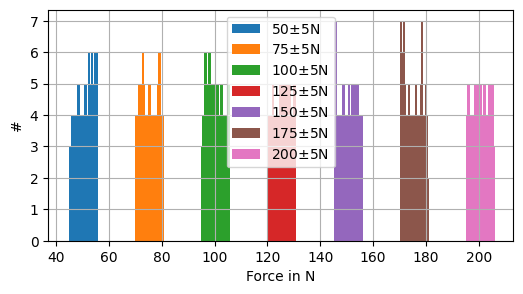

In [5]:
plt.figure(figsize=(6, 3))
for tars_kys, tars_vls in targets_F.items():
    plt.hist(F[tars_vls], bins=len(F[tars_vls]), label=tars_kys, align="mid", width=1)
plt.grid()
plt.legend(y_label)
plt.ylabel("#")
plt.xlabel("Force in N")  # Adjustment place
plt.show()

In [6]:
def encode_targets(
    y,
    n_classes,
    encoding="ordinal",
):
    """encoding= "ordinal", "onehot", "thermometer"""

    y_cont = y.reshape(-1, 1)

    binning = KBinsDiscretizer(
        n_bins=n_classes,
        encode="ordinal",
        strategy="quantile",
        quantile_method="averaged_inverted_cdf",
    )

    y_binned = binning.fit_transform(y_cont).astype(int).ravel()
    if encoding == "ordinal":
        return y_binned

    elif encoding == "onehot":
        y_encoded = np.zeros((len(y_binned), n_classes), dtype=int)
        y_encoded[np.arange(len(y_binned)), y_binned] = 1
        return y_encoded

    elif encoding == "thermometer":
        # cumulative / thermometer encoding
        y_encoded = np.zeros((len(y_binned), n_classes), dtype=int)
        for i, cls in enumerate(y_binned):
            y_encoded[i, : cls + 1] = 1
        return y_encoded

    else:
        raise ValueError(
            f"Unknown encoding '{encoding}'. "
            "Choose from: 'ordinal', 'onehot', 'thermometer'."
        )

In [7]:
yyy = np.array([0.1, 0.5, 0.9, 1.3])
n_classes_ex = 4

print("ordinal", encode_targets(yyy, n_classes_ex, encoding="ordinal"))
print("onehot", encode_targets(yyy, n_classes_ex, encoding="onehot"))
print("thermometer", encode_targets(yyy, n_classes_ex, encoding="thermometer"))

ordinal [0 1 2 3]
onehot [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
thermometer [[1 0 0 0]
 [1 1 0 0]
 [1 1 1 0]
 [1 1 1 1]]


In [8]:
y = F[targets]  # F -> Force # Adjustment place
EIT = X[targets]
Pwise = P[targets]

encod_type = "ordinal"  # 'ordinal', 'onehot', 'thermometer'

y = encode_targets(y, n_classes, encoding=encod_type)

## RF: $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$

In [9]:
# Adjustment place
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [None, 5, 10],
    "min_samples_split": [1, 2, 5],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

_Train/Valid_

In [10]:
params_path = f"params/TrainValid_F_RF_{n_classes}_{encod_type}.pkl"

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=80,
        verbose=1,
    )
    grid.fit(EIT, y)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Loaded params
beste parameter: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [11]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.3f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.831
Fold 2 Balanced Accuracy: 0.827
Fold 3 Balanced Accuracy: 0.820
Fold 4 Balanced Accuracy: 0.823
Fold 5 Balanced Accuracy: 0.817

Mean Balanced Accuracy: 0.8238294112277499
Std Balanced Accuracy: 0.004982736279343717

accuracy_score: 0.8238301757589591
balanced_accuracy_score: 0.8238287342726185
r2_score: 0.9262847943953275



Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      3129
           1       0.81      0.85      0.83      3129
           2       0.80      0.78      0.79      3129
           3       0.78      0.77      0.77      3130
           4       0.77      0.77      0.77      3129
           5       0.79      0.81      0.80      3129
           6       0.91      0.91      0.91      3130

    accuracy                           0.82     21905
   macro avg       0.82      0.82      0.82     21905
weighted avg       0.82      0.82      0.82     21905



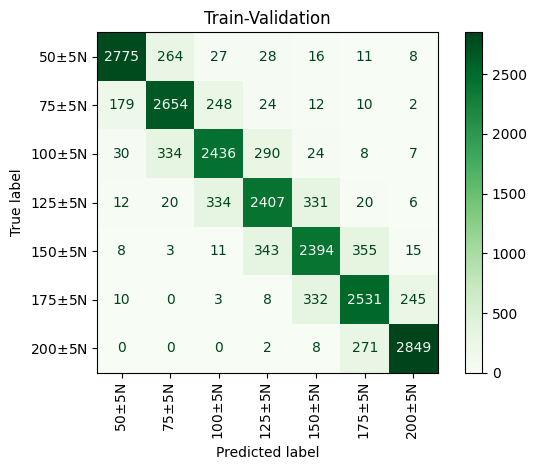

In [12]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.xticks(rotation=90)
plt.title("Train-Validation")
plt.tight_layout()
plt.savefig(
    f"imgs/TrainValid_F_RF_{n_classes}_{encod_type}.pdf", bbox_inches="tight"
)  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [13]:
params_path = f"params/TrainTest_F_RF_{n_classes}_{encod_type}.pkl"

cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=80,
        verbose=1,
        refit=True,
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Loaded params
Best parameter: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [14]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.3f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.151
Fold 2 Accuracy: 0.179
Fold 3 Accuracy: 0.192
Fold 4 Accuracy: 0.144
Fold 5 Accuracy: 0.128

Mean Accuracy: 0.15881146831666504
Std Accuracy: 0.023419097333459416

accuracy_score 0.15672220954120064
balanced_accuracy_score 0.15671179593908022
r2_score: -1.4530192648778262



Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.08      0.11      3129
           1       0.21      0.24      0.22      3129
           2       0.11      0.01      0.02      3129
           3       0.16      0.10      0.12      3130
           4       0.15      0.05      0.08      3129
           5       0.12      0.17      0.14      3129
           6       0.16      0.44      0.23      3130

    accuracy                           0.16     21905
   macro avg       0.15      0.16      0.13     21905
weighted avg       0.15      0.16      0.13     21905



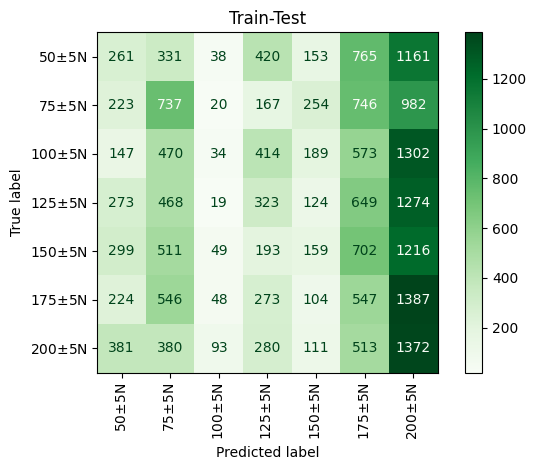

In [15]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.xticks(rotation=90)
plt.title("Train-Test")
plt.tight_layout()
plt.savefig(
    f"imgs/TrainTest_F_RF_{n_classes}_{encod_type}.pdf", bbox_inches="tight"
)  # Adjustment place
plt.show()

___

## SVM: $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$

_Train/Valid_

In [16]:
param_grid = [
    {"svm__kernel": ["linear"], "svm__C": [0.01, 0.1, 1, 10, 100]},
    {
        "svm__kernel": ["rbf"],
        "svm__C": [100],
        "svm__gamma": ["scale", "auto", 0.01, 0.1, 1],
    },
    {
        "svm__kernel": ["sigmoid"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": ["scale", "auto", 0.01, 0.1, 1],
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.01, 0.1, 1, 10],
        "svm__degree": [2, 3, 4],
        "svm__gamma": ["scale", "auto"],
    },
]

In [17]:
params_path = f"params/TrainValid_F_SVM_{n_classes}_{encod_type}.pkl"

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Loaded params
beste parameter: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}


In [18]:
best_model = SVC(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.3f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.569
Fold 2 Balanced Accuracy: 0.569
Fold 3 Balanced Accuracy: 0.562
Fold 4 Balanced Accuracy: 0.562
Fold 5 Balanced Accuracy: 0.564

Mean Balanced Accuracy: 0.5651673208580557
Std Balanced Accuracy: 0.003094553616501651

accuracy_score: 0.5651677699155444
balanced_accuracy_score: 0.5651640204509017
r2_score: 0.557845719842666



Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.63      0.64      3129
           1       0.61      0.63      0.62      3129
           2       0.52      0.47      0.49      3129
           3       0.48      0.44      0.46      3130
           4       0.46      0.44      0.45      3129
           5       0.54      0.58      0.56      3129
           6       0.67      0.77      0.71      3130

    accuracy                           0.57     21905
   macro avg       0.56      0.57      0.56     21905
weighted avg       0.56      0.57      0.56     21905



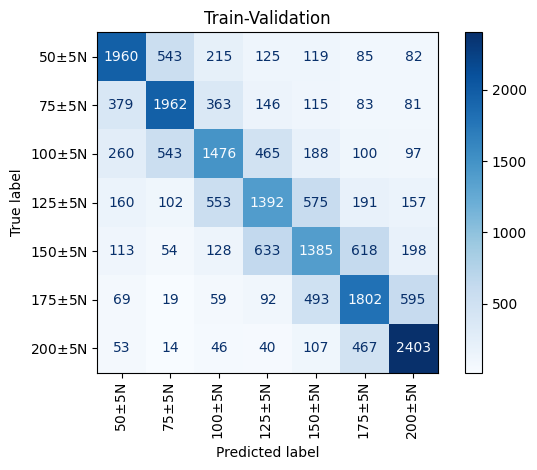

In [19]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.xticks(rotation=90)
plt.title("Train-Validation")
plt.tight_layout()
plt.savefig(
    f"imgs/TrainValid_F_SVM_{n_classes}_{encod_type}.pdf", bbox_inches="tight"
)  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [20]:
params_path = f"params/TrainTest_F_SVM_{n_classes}_{encod_type}.pkl"


pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])  # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Loaded params
Best parameter: {'C': 0.1, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}


In [21]:
best_model = SVC(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.3f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.169
Fold 2 Accuracy: 0.171
Fold 3 Accuracy: 0.169
Fold 4 Accuracy: 0.118
Fold 5 Accuracy: 0.142

Mean Accuracy: 0.15386212074163472
Std Accuracy: 0.021006459061765455

accuracy_score 0.15147226660579777
balanced_accuracy_score 0.15147914001889537
r2_score: -1.001700514972768



Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.08      0.11      3129
           1       0.17      0.55      0.27      3129
           2       0.14      0.12      0.13      3129
           3       0.15      0.02      0.03      3130
           4       0.12      0.08      0.09      3129
           5       0.12      0.09      0.10      3129
           6       0.12      0.14      0.13      3130

    accuracy                           0.15     21905
   macro avg       0.14      0.15      0.12     21905
weighted avg       0.14      0.15      0.12     21905



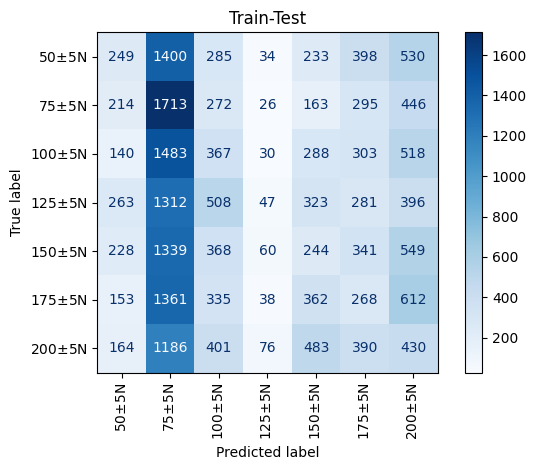

In [22]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.xticks(rotation=90)
plt.title("Train-Test")
plt.tight_layout()
plt.savefig(
    f"imgs/TrainTest_F_SVM_{n_classes}_{encod_type}.pdf", bbox_inches="tight"
)  # Adjustment place
plt.show()

___

## LR: $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$

_Train/Valid_

In [23]:
param_grid = [
    {
        "LR__penalty": ["l2"],
        "LR__C": [0.01, 0.1, 1, 10, 100],
        "LR__solver": ["lbfgs", "newton-cg"],
        "LR__class_weight": [None, "balanced"],
    },
    {
        "LR__penalty": ["l1"],
        "LR__C": [0.01, 0.1, 1, 10],
        "LR__solver": ["liblinear", "saga"],
        "LR__class_weight": [None, "balanced"],
    },
    {
        "LR__penalty": ["elasticnet"],
        "LR__C": [0.01, 0.1, 1, 10],
        "LR__solver": ["saga"],
        "LR__l1_ratio": [0.1, 0.5, 0.9],
        "LR__class_weight": ["balanced"],
    },
]

In [24]:
params_path = f"params/TrainValid_F_LR_{n_classes}_{encod_type}.pkl"

pipe = Pipeline(
    [("scaler", StandardScaler()), ("LR", LogisticRegression())]
)  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("LR__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Loaded params
beste parameter: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'newton-cg'}


In [25]:
best_model = LogisticRegression(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.3f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.425
Fold 2 Balanced Accuracy: 0.417
Fold 3 Balanced Accuracy: 0.421
Fold 4 Balanced Accuracy: 0.416
Fold 5 Balanced Accuracy: 0.423

Mean Balanced Accuracy: 0.42040668188041985
Std Balanced Accuracy: 0.0037190610389748417

accuracy_score: 0.4204062999315225
balanced_accuracy_score: 0.42040292670019525
r2_score: 0.12332659567689808



Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.50      0.48      3129
           1       0.39      0.50      0.44      3129
           2       0.38      0.32      0.35      3129
           3       0.37      0.31      0.34      3130
           4       0.33      0.31      0.32      3129
           5       0.42      0.40      0.41      3129
           6       0.54      0.60      0.57      3130

    accuracy                           0.42     21905
   macro avg       0.42      0.42      0.42     21905
weighted avg       0.42      0.42      0.42     21905



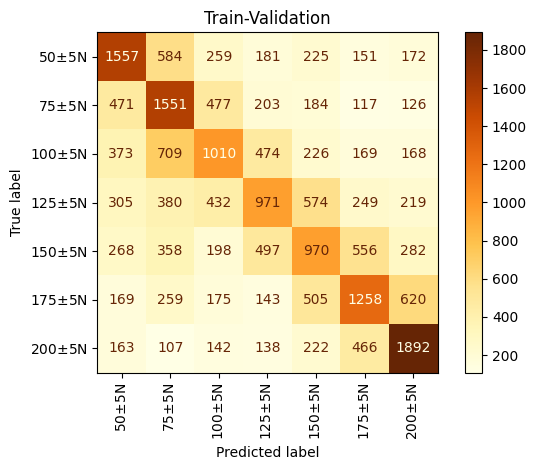

In [26]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="YlOrBr", values_format="d")
plt.xticks(rotation=90)
plt.title("Train-Validation")
plt.tight_layout()
plt.savefig(
    f"imgs/TrainValid_F_LR_{n_classes}_{encod_type}.pdf", bbox_inches="tight"
)  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [27]:
params_path = f"params/TrainTest_F_LR_{n_classes}_{encod_type}.pkl"

pipe = Pipeline(
    [("scaler", StandardScaler()), ("LR", LogisticRegression())]
)  # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("LR__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Loaded params
Best parameter: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'newton-cg'}


In [28]:
best_model = LogisticRegression(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.3f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.159
Fold 2 Accuracy: 0.165
Fold 3 Accuracy: 0.195
Fold 4 Accuracy: 0.127
Fold 5 Accuracy: 0.164

Mean Accuracy: 0.1619272892812067
Std Accuracy: 0.021484229063034745

accuracy_score 0.16630906185802327
balanced_accuracy_score 0.16631390596850268
r2_score: -0.9581721368683831



Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.12      0.18      3129
           1       0.20      0.25      0.22      3129
           2       0.16      0.17      0.16      3129
           3       0.14      0.04      0.06      3130
           4       0.15      0.16      0.16      3129
           5       0.15      0.23      0.19      3129
           6       0.13      0.19      0.15      3130

    accuracy                           0.17     21905
   macro avg       0.18      0.17      0.16     21905
weighted avg       0.18      0.17      0.16     21905



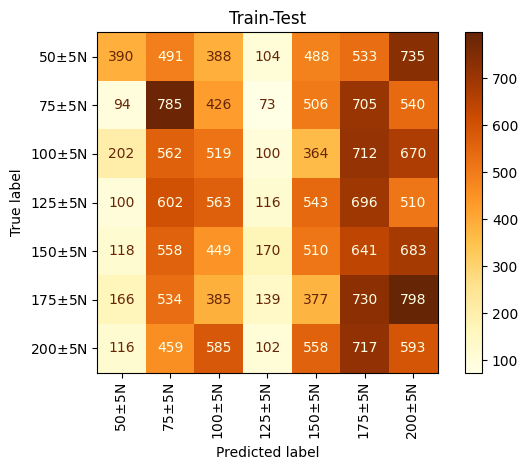

In [29]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="YlOrBr", values_format="d")
plt.xticks(rotation=90)
plt.title("Train-Test")
plt.tight_layout()
plt.savefig(
    f"imgs/TrainTest_F_LR_{n_classes}_{encod_type}.pdf", bbox_inches="tight"
)  # Adjustment place
plt.show()

___